# Autoregressive joint smoothing with BayesFlow

This smoke example constructs and builds an `AutoregressiveApproximator` for
$p(\theta_{1:T} \mid x_{1:T}, c) = \prod_t p(\theta_t \mid x_{1:T}, c, \theta_{<t})$, then draws complete trajectories from an untrained coupling flow. In a real Superstats workflow, replace the synthetic arrays with adapted simulator output and train before sampling.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import bayesflow as bf
import superstats as sup

import keras

INFO:bayesflow:Multiple Keras-compatible backends detected (JAX, PyTorch, TensorFlow). Defaulting to JAX.
To override, set the KERAS_BACKEND environment variable before importing bayesflow.
See: https://keras.io/getting_started/#configuring-your-backend
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


In [2]:
joint_prior = sup.JointPrior(
    v=sup.transition.RandomWalk(bounds=(-6, 6)), 
    a=sup.transition.RandomWalk(bounds=(0.1, 4.0)),
    tau=0.3,
    bias=0.5
)

model = sup.Model(
    prior=joint_prior, 
    simulator=sup.simulation.sample_ddm, 
    missing=None,
    contamination=None
)

/home/radevs/anaconda3/envs/bfjax/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [3]:
adapter = (bf.Adapter()
    .convert_dtype("float64", "float32")
    .as_time_series(["time_steps", "response_time", "choice"])
    .concatenate(["time_steps", "response_time", "choice"], into="summary_variables")
    .concatenate(["v", "a"], into="inference_variables")
)

In [4]:
epochs = 200
num_train = 10_000
num_val = 100
batch_size = 32

train_data = model.sample(num_train, num_steps=100)
val_data = model.sample(num_val, num_steps=100)

train_dataset = bf.OfflineDataset(
    data=train_data,
    batch_size=batch_size,
    adapter=adapter
)

val_dataset = bf.OfflineDataset(
    data=val_data,
    batch_size=batch_size,
    adapter=adapter
)

In [ ]:
encoder = bf.networks.RecurrentNetwork(return_sequences=True)
decoder = bf.networks.RecurrentDecoder()

inference_network = bf.networks.CouplingFlow()

approximator = bf.AutoregressiveApproximator(
    inference_network=inference_network,
    encoder_network=encoder,
    decoder_network=decoder,
    adapter=adapter,
    standardize="all"
)

optimizer = keras.optimizers.AdamW(
    learning_rate=keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=4e-4,
        decay_steps=epochs * (num_train // batch_size)
    )
)

approximator.compile(optimizer=optimizer)

In [6]:
h = approximator.fit(
    dataset=train_dataset,
    validation_data=val_dataset,
    epochs=epochs
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 68ms/step - loss: -0.3390 - val_loss: -1.7748
Epoch 2/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: -1.8401 - val_loss: -2.1551
Epoch 3/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: -2.0823 - val_loss: -2.2450
Epoch 4/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: -2.1806 - val_loss: -2.1134
Epoch 5/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: -2.2109 - val_loss: -2.4222
Epoch 6/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: -2.2666 - val_loss: -2.4617
Epoch 7/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: -2.3176 - val_loss: -2.4326
Epoch 8/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: -2.3048 - val_loss: -2.4605
Epoch 9/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: -2.4001 - val_loss: -2.6112
Epoch 10/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: -2.4380 - val_loss: -2.6535
Epoch 11/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: -2.4402 - val_loss: -2.7219


In [7]:
test_data = model.sample(10, num_steps=100)
samples = approximator.sample(conditions=test_data, num_samples=300)

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

/tmp/ipykernel_2770158/36406732.py:81: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


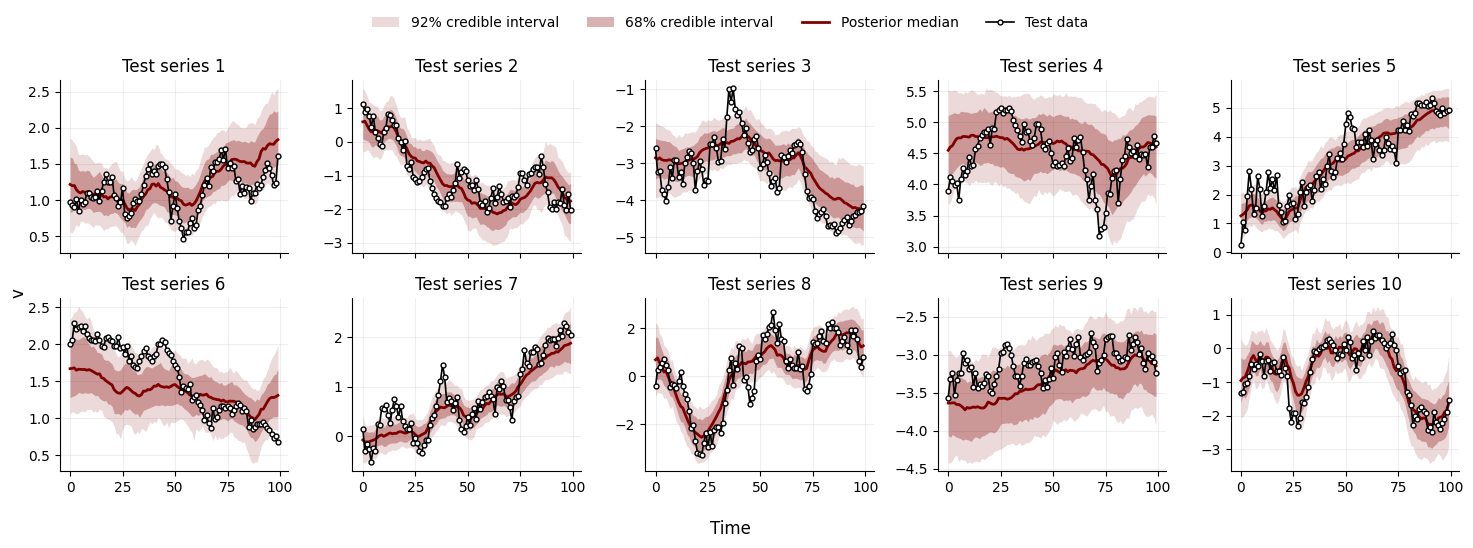

In [8]:
fig, axarr = plt.subplots(
    2, 5,
    figsize=(15, 5),
    sharex=True,
    constrained_layout=True,
)

for i, ax in enumerate(axarr.flat):
    posterior = samples["v"][i].squeeze()
    observed = test_data["v"][i].squeeze()

    # Quantiles are computed across posterior samples (axis 0).
    ci92_low, ci68_low, median, ci68_high, ci92_high = np.quantile(
        posterior,
        [0.04, 0.16, 0.50, 0.84, 0.96],
        axis=0,
    )

    time = np.arange(median.size)

    # Posterior credible intervals
    ax.fill_between(
        time,
        ci92_low,
        ci92_high,
        color="maroon",
        alpha=0.15,
        linewidth=0,
        label="92% credible interval",
    )
    ax.fill_between(
        time,
        ci68_low,
        ci68_high,
        color="maroon",
        alpha=0.30,
        linewidth=0,
        label="68% credible interval",
    )

    # Posterior median
    ax.plot(
        time,
        median,
        color="maroon",
        linewidth=2,
        label="Posterior median",
    )

    # Real test data: connected dots
    ax.plot(
        time,
        observed,
        color="black",
        marker="o",
        markersize=3.5,
        linewidth=1.2,
        markerfacecolor="white",
        markeredgewidth=1,
        label="Test data",
        zorder=3,
    )

    ax.set_title(f"Test series {i + 1}")
    ax.grid(alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)

# One shared legend
handles, labels = axarr.flat[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1.08),
)

fig.supxlabel("Time")
fig.supylabel("v")
fig.tight_layout()